# BC Warm-Up: Pretraining + Evaluation


## Cell 1: Imports & Config

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from torch.utils.data import DataLoader, TensorDataset
from sentence_transformers import SentenceTransformer
from collections import defaultdict
from sklearn.model_selection import train_test_split
import json, warnings, math
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.figsize'] = (16, 4)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

class Config:
    DATA_DIR  = '/kaggle/input/datasets/rehabbb/dbe-kt22-dataset/DBE_KT22_dataset/'
    JSON_PATH = DATA_DIR + 'Practice_Sequences.json'
    Q_KC_PATH = DATA_DIR + 'Question_KC_Relationships.csv'
    KCS_PATH  = DATA_DIR + 'KCs.csv'

    DIFF_MAP    = {'1': 0, '2': 1, '3': 2}
    N_LEVELS    = 3
    LEVEL_NAMES = ['Easy', 'Medium', 'Hard']


    GAMMA_LEVEL = np.array([0.0330, 0.1494, 0.8884])
    RHO_LEVEL   = np.array([0.1444, 0.3433, 0.2331])
    BETA_LEVEL  = np.array([1.4333, 1.0389, 0.4271])

    PFA_TOP_K = 3
    PFA_ALPHA = 0.05

    LLM_BETA_SCALE = -0.4
    LLM_BETA_MID   = 3.0

    # ── Embedding ─────────────────────────────────────────────────────────
    EMBED_MODEL = 'BAAI/bge-base-en-v1.5'
    EMBED_DIM   = 768

   
    GLOBAL_FEATS  = 8    # global PFA summary scalars
    CONCEPT_FEATS = 6    # per-concept scalars
    STATE_DIM     = 8 + 6   # = 14 total state features
    SCORER_IN     = 8 + 6 + 3   # state + difficulty one-hot = 17
    HIDDEN_DIM    = 64

    # ── BC pretraining ────────────────────────────────────────────────────
    BC_LR     = 5e-4
    BC_EPOCHS = 15
    BC_BATCH  = 512   # large batch fine now — no N encoder passes per sample

    # ── APR-relative session goal ─────────────────────────────────────────
    IMPROVEMENT_TARGET = 0.08

    # ── Eval ──────────────────────────────────────────────────────────────
    EVAL_STEPS       = 20
    EVAL_N_SESSIONS  = 50

    DEVICE = DEVICE

cfg = Config()
print('Config loaded.')
print(f'  State dim      : {cfg.STATE_DIM} scalars  (global={cfg.GLOBAL_FEATS} + concept={cfg.CONCEPT_FEATS})')
print(f'  Scorer input   : {cfg.SCORER_IN}  (state + difficulty one-hot)')
print(f'  BC batch size  : {cfg.BC_BATCH}  (larger now — no per-concept encoder passes)')
print(f'  IMPROVEMENT_TARGET: +{cfg.IMPROVEMENT_TARGET*100:.0f}pp from session start')


Device: cuda
Config loaded.
  State dim      : 14 scalars  (global=8 + concept=6)
  Scorer input   : 17  (state + difficulty one-hot)
  BC batch size  : 512  (larger now — no per-concept encoder passes)
  IMPROVEMENT_TARGET: +8pp from session start


## Cell 2: Load Data

In [35]:
df_kcs  = pd.read_csv(cfg.KCS_PATH)
df_q_kc = pd.read_csv(cfg.Q_KC_PATH)
df_merged = df_q_kc.merge(df_kcs, left_on='knowledgecomponent_id', right_on='id')

q_to_concept    = dict(zip(df_merged['question_id'].astype(str), df_merged['name']))
unique_concepts = list(dict.fromkeys(q_to_concept.values()))
concept_idx     = {c: i for i, c in enumerate(unique_concepts)}

with open(cfg.JSON_PATH, 'r') as f:
    trajectories = json.load(f)

print(f'Concepts : {len(unique_concepts)}')
print(f'Students : {len(trajectories)}')
seq_lens = [int(t['seq_len']) for t in trajectories]
print(f'Seq len  : min={min(seq_lens)} mean={np.mean(seq_lens):.1f} max={max(seq_lens)}')

Concepts : 69
Students : 15392
Seq len  : min=1 mean=9.6 max=10


## Cell 3: Embeddings + Similarity Graph

In [36]:
embed_model = SentenceTransformer(cfg.EMBED_MODEL)

concept_embeddings = embed_model.encode(
    unique_concepts, normalize_embeddings=True, show_progress_bar=True
).astype(np.float32)

sim_matrix = concept_embeddings @ concept_embeddings.T

N = len(unique_concepts)
neighbours = []
for i in range(N):
    s = sim_matrix[i].copy(); s[i] = -1
    neighbours.append(np.argsort(-s)[:cfg.PFA_TOP_K])

print(f'Embedding matrix : {concept_embeddings.shape}')
print(f'Example — neighbours of "{unique_concepts[0]}":')
for j in neighbours[0]:
    print(f'  "{unique_concepts[j]}"  sim={sim_matrix[0,j]:.3f}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding matrix : (69, 768)
Example — neighbours of "Data type":
  "Data structure"  sim=0.742
  "Relational data model"  sim=0.688
  "Key attributes"  sim=0.681


## Cell 4: PFA Tracker

Pre-trained global params, dynamic per-concept beta.

### New method: `get_state_features(concept)`

Returns the 14-scalar feature vector for one (student state, target concept) pair.
This is all the actor needs — no token matrices, no attention.

```
Global (8):  mean_p, std_p, mean_p_easy, mean_p_med, mean_p_hard,
             frac_unexplored, log_s_total, log_f_total
Concept (6): p_easy, p_med, p_hard, log_s_c, log_f_c, max_sim_to_seen
```

`max_sim_to_seen` captures how related this concept is to concepts the student
has already practiced. High similarity → the student likely has transferable
knowledge. This is the only embedding-based feature, and it reduces to a single
scalar — no variable-size structure needed.

In [ ]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -15, 15)))


class PFATracker:

    def __init__(self, concepts, embeddings, neighbours, sim_matrix, cfg):
        self.concepts   = list(concepts)
        self.embeddings = embeddings.copy()
        self.neighbours = [n.copy() for n in neighbours]
        self.sim_matrix = sim_matrix.copy()
        self.cfg        = cfg
        N, L = len(concepts), cfg.N_LEVELS

        self.gamma_level = cfg.GAMMA_LEVEL.copy()
        self.rho_level   = cfg.RHO_LEVEL.copy()
        self.beta_level  = cfg.BETA_LEVEL.copy()
        self.beta_concept = np.zeros(N)
        self.idx          = {c: i for i, c in enumerate(self.concepts)}

        self.successes         = np.zeros((N, L))
        self.failures          = np.zeros((N, L))
        self.propagation_bonus = np.zeros((N, L))

        self.apr_start  = None
        self.apr_target = None

    def reset(self):
        N, L = len(self.concepts), self.cfg.N_LEVELS
        self.successes         = np.zeros((N, L))
        self.failures          = np.zeros((N, L))
        self.propagation_bonus = np.zeros((N, L))
        self.apr_start  = self.compute_apr()
        self.apr_target = min(0.97, self.apr_start + self.cfg.IMPROVEMENT_TARGET)
        return self.apr_start, self.apr_target

    def predict(self, concept, level):
        i, k = self.idx[concept], level
        z = (
            self.beta_concept[i]
            + self.beta_level[k]
            + self.gamma_level[k] * np.log1p(self.successes[i, k])
            - self.rho_level[k]   * np.log1p(self.failures[i, k])
            + self.propagation_bonus[i, k]
        )
        return sigmoid(z)

    def predict_all(self):
        z = (
            self.beta_concept[:, None]
            + self.beta_level[None, :]
            + self.gamma_level[None, :] * np.log1p(self.successes)
            - self.rho_level[None, :]   * np.log1p(self.failures)
            + self.propagation_bonus
        )
        return sigmoid(z)

    def compute_apr(self):
        return float(self.predict_all().mean())

    def goal_met(self):
        if self.apr_target is None:
            return False
        return self.compute_apr() >= self.apr_target

    def update(self, concept, level, correct, confidence=None, hint_used=False):
        i, k = self.idx[concept], level
        p_before = self.predict(concept, level)
        if correct:
            credit = 0.4 if (hint_used or confidence == 1) else 1.0
            self.successes[i, k] += credit
        else:
            self.failures[i, k] += 1.0
        p_after = self.predict(concept, level)
        delta = np.clip(p_after - p_before, -0.1, 0.1)
        for j in self.neighbours[i]:
            sim = self.sim_matrix[i, j]
            for lvl in range(k + 1):
                self.propagation_bonus[j, lvl] += cfg.PFA_ALPHA * sim / (lvl + 1) * delta
        return p_before, p_after

    def get_state_features(self, concept_name):
        """
        Compute the 14-scalar feature vector for (student_state, target_concept).
        Fixed size regardless of number of concepts. No attention needed.

        Global features (8):
          mean_p_all, std_p_all           overall mastery level and spread
          mean_p_easy, mean_p_med,        per-difficulty mastery
          mean_p_hard
          frac_unexplored                 fraction of concepts with 0 interactions
          log_s_total, log_f_total        log total successes/failures

        Concept features (6):
          p_easy, p_med, p_hard           concept-specific mastery at each level
          log_s_c, log_f_c                concept-level practice volume
          max_sim_seen                    similarity to most-practiced similar concept
                                          high = student likely has transferable knowledge

        Returns: np.float32 array of shape (14,)
        """
        ci = self.idx[concept_name]
        all_p = self.predict_all()          # (N, L)

        mean_p_all   = float(all_p.mean())
        std_p_all    = float(all_p.std())
        mean_p_easy  = float(all_p[:, 0].mean())
        mean_p_med   = float(all_p[:, 1].mean())
        mean_p_hard  = float(all_p[:, 2].mean())

   
        total_interactions = self.successes.sum(axis=1) + self.failures.sum(axis=1)
        frac_unexplored    = float((total_interactions == 0).mean())

        log_s_total = float(np.log1p(self.successes.sum()))
        log_f_total = float(np.log1p(self.failures.sum()))

  
        p_easy = float(all_p[ci, 0])
        p_med  = float(all_p[ci, 1])
        p_hard = float(all_p[ci, 2])

        log_s_c = float(np.log1p(self.successes[ci].sum()))
        log_f_c = float(np.log1p(self.failures[ci].sum()))

        practiced_mask = (total_interactions > 0)
        if practiced_mask.any():
            sims = self.sim_matrix[ci] 
            max_sim_seen = float(sims[practiced_mask].max())
        else:
            max_sim_seen = 0.0

        feats = np.array([
            mean_p_all, std_p_all,
            mean_p_easy, mean_p_med, mean_p_hard,
            frac_unexplored, log_s_total, log_f_total,
            p_easy, p_med, p_hard,
            log_s_c, log_f_c, max_sim_seen
        ], dtype=np.float32)
        return feats   # (14,)

    def add_concept(self, name, embedding, beta_init=0.0):
        i = len(self.concepts)
        self.concepts.append(name)
        self.idx[name] = i
        L = self.cfg.N_LEVELS
        self.embeddings  = np.vstack([self.embeddings, embedding[None]])
        self.beta_concept = np.append(self.beta_concept, beta_init)
        self.successes         = np.vstack([self.successes,         np.zeros((1, L))])
        self.failures          = np.vstack([self.failures,          np.zeros((1, L))])
        self.propagation_bonus = np.vstack([self.propagation_bonus, np.zeros((1, L))])
        new_sims = (self.embeddings @ embedding).astype(np.float32)
        self.sim_matrix = np.block([
            [self.sim_matrix,      new_sims[:-1, None]],
            [new_sims[None, :-1],  np.array([[1.0]])  ]
        ])
        sims_new = self.sim_matrix[-1].copy(); sims_new[-1] = -1
        self.neighbours.append(np.argsort(-sims_new)[:self.cfg.PFA_TOP_K])
        print(f'  Added "{name}" (beta_init={beta_init:.3f}) -> '
              f'P(Easy)={self.predict(name,0):.3f}  '
              f'P(Med)={self.predict(name,1):.3f}  '
              f'P(Hard)={self.predict(name,2):.3f}')


tracker = PFATracker(unique_concepts, concept_embeddings, neighbours, sim_matrix, cfg)


apr_s, apr_t = tracker.reset()
feats = tracker.get_state_features(unique_concepts[0])
print(f'State features for "{unique_concepts[0]}" at session start:')
labels = ['mean_p_all','std_p_all','mean_p_easy','mean_p_med','mean_p_hard',
          'frac_unexplored','log_s_total','log_f_total',
          'p_easy','p_med','p_hard','log_s_c','log_f_c','max_sim_seen']
for lab, val in zip(labels, feats):
    print(f'  {lab:<20}: {val:.4f}')
print(f'Feature vector shape: {feats.shape}  (expected: (14,))')
print(f'APR start={apr_s:.4f}  target={apr_t:.4f}')


State features for "Data type" at session start:
  mean_p_all          : 0.7171
  std_p_all           : 0.0840
  mean_p_easy         : 0.8074
  mean_p_med          : 0.7386
  mean_p_hard         : 0.6052
  frac_unexplored     : 1.0000
  log_s_total         : 0.0000
  log_f_total         : 0.0000
  p_easy              : 0.8074
  p_med               : 0.7386
  p_hard              : 0.6052
  log_s_c             : 0.0000
  log_f_c             : 0.0000
  max_sim_seen        : 0.0000
Feature vector shape: (14,)  (expected: (14,))
APR start=0.7171  target=0.7971


## Cell 5: EPPOActor 

In [ ]:
class EPPOActor(nn.Module):
 
    def __init__(self, cfg):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(cfg.SCORER_IN, cfg.HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM, cfg.HIDDEN_DIM // 2),
            nn.ReLU(),
            nn.Linear(cfg.HIDDEN_DIM // 2, 1)
        )

    def score_action(self, state_feats_t, diff_oh_t):
    
        x = torch.cat([state_feats_t, diff_oh_t])
        return self.scorer(x).squeeze(-1)

    def get_policy(self, tracker, cfg):
  
        N = len(tracker.concepts)
        L = cfg.N_LEVELS
        diff_ohs = torch.eye(L, device=DEVICE)  

       
        all_feats = np.stack(
            [tracker.get_state_features(c) for c in tracker.concepts], axis=0
        )  # (N, 14)
        feats_t = torch.tensor(all_feats, dtype=torch.float32).to(DEVICE)  # (N, 14)

        # Expand: feats_t -> (N*L, 14), diff_ohs -> (N*L, L)
        feats_exp = feats_t.repeat_interleave(L, dim=0)          # (N*L, 14)
        diff_exp  = diff_ohs.repeat(N, 1)                        # (N*L, L)

        # Single batched MLP call over all actions
        x      = torch.cat([feats_exp, diff_exp], dim=1)          # (N*L, 17)
        logits = self.scorer(x).squeeze(-1)                        # (N*L,)

        return Categorical(logits=logits), logits


actor = EPPOActor(cfg).to(DEVICE)
total_params = sum(p.numel() for p in actor.parameters())
print(f'Actor params: {total_params:,}')
print(f'  Input dim : {cfg.SCORER_IN}  (14 PFA features + 3 difficulty one-hot)')
print(f'  Hidden dim: {cfg.HIDDEN_DIM}')
print()
print('Speed comparison vs AttentionEncoder approach:')
print(f'  Old: 69 encoder forward passes per sample (each ~768->128 with attention)')
print(f'  New: 1 batched MLP call over all (N*L) actions - one matrix multiply')
print(f'  Speedup: ~20-50x per training sample')


Actor params: 3,265
  Input dim : 17  (14 PFA features + 3 difficulty one-hot)
  Hidden dim: 64

Speed comparison vs AttentionEncoder approach:
  Old: 69 encoder forward passes per sample (each ~768->128 with attention)
  New: 1 batched MLP call over all (N*L) actions — one matrix multiply
  Speedup: ~20-50x per training sample


## Cell 6: EPPO Actor (removed AttentionEncoder — see above)## Cell 7: Build BC Dataset


In [ ]:
def build_bc_dataset_full(
    trajectories,
    q_to_concept,
    concept_idx,
    concept_embeddings,
    sim_matrix,
    neighbours,
    cfg,
    max_seqs=None
):
    

    print('Building FULL BC dataset (all concept features)...')

    N_c = len(unique_concepts)
    L   = cfg.N_LEVELS

    all_feats   = []
    all_actions = []

    seqs = trajectories if max_seqs is None else trajectories[:max_seqs]

    total_steps = 0

    for seq_i, seq in enumerate(seqs):

        if seq_i % 1000 == 0:
            print(f'[{seq_i}/{len(seqs)}] steps={total_steps}')

        s_counts = np.zeros((N_c, L), dtype=np.float32)
        f_counts = np.zeros((N_c, L), dtype=np.float32)
        bonuses  = np.zeros((N_c, L), dtype=np.float32)
        beta_c   = np.zeros(N_c, dtype=np.float32)

        qids     = seq['question_ids'].split(',')
        ans_raw  = seq['answers'].split(',')
        diff_raw = seq['gt_difficulty'].split(',')
        conf_raw = seq['answer_confidence'].split(',')
        hint_raw = seq['hint_used'].split(',')

        for qid, ans_s, diff_s, conf_s, hint_s in zip(
            qids, ans_raw, diff_raw, conf_raw, hint_raw
        ):

            concept = q_to_concept.get(qid.strip())

            if concept is None or concept not in concept_idx:
                continue

            ci      = concept_idx[concept]
            correct = int(ans_s.strip())
            k       = cfg.DIFF_MAP.get(diff_s.strip(), 0)

            conf = (
                int(conf_s.strip())
                if conf_s.strip().isdigit()
                else 0
            )

            hint = hint_s.strip().lower() == 'true'

       
            z_all = (
                beta_c[:, None]
                + cfg.BETA_LEVEL[None, :]
                + cfg.GAMMA_LEVEL[None, :] * np.log1p(s_counts)
                - cfg.RHO_LEVEL[None, :]   * np.log1p(f_counts)
                + bonuses
            )

            all_p = sigmoid(z_all)   # (N, L)

            total_int = (
                s_counts.sum(axis=1)
                + f_counts.sum(axis=1)
            )

            practiced_mask = (total_int > 0)


            global_feats = np.array([
                float(all_p.mean()),
                float(all_p.std()),
                float(all_p[:,0].mean()),
                float(all_p[:,1].mean()),
                float(all_p[:,2].mean()),
                float((total_int == 0).mean()),
                float(np.log1p(s_counts.sum())),
                float(np.log1p(f_counts.sum()))
            ], dtype=np.float32)

          
            concept_feats_all = np.zeros(
                (N_c, cfg.STATE_DIM),
                dtype=np.float32
            )

            for cj in range(N_c):

                if practiced_mask.any():
                    max_sim = float(
                        sim_matrix[cj][practiced_mask].max()
                    )
                else:
                    max_sim = 0.0

                concept_feats = np.array([
                    float(all_p[cj,0]),
                    float(all_p[cj,1]),
                    float(all_p[cj,2]),
                    float(np.log1p(s_counts[cj].sum())),
                    float(np.log1p(f_counts[cj].sum())),
                    max_sim
                ], dtype=np.float32)

                concept_feats_all[cj] = np.concatenate([
                    global_feats,
                    concept_feats
                ])

            all_feats.append(concept_feats_all)

            action_id = ci * L + k
            all_actions.append(action_id)

            total_steps +=  1



            credit = (
                0.4 if (hint or conf == 1) else 1.0
            ) if correct else 0.0

            p_before = float(all_p[ci, k])

            s_counts[ci, k] += credit
            f_counts[ci, k] += (1 - correct)

            p_after = float(sigmoid(
                beta_c[ci]
                + cfg.BETA_LEVEL[k]
                + cfg.GAMMA_LEVEL[k] * np.log1p(s_counts[ci, k])
                - cfg.RHO_LEVEL[k]   * np.log1p(f_counts[ci, k])
                + bonuses[ci, k]
            ))

            delta = np.clip(
                p_after - p_before,
                -0.1,
                0.1
            )

            for j in neighbours[ci]:

                sim_j = sim_matrix[ci, j]

                for lvl in range(k + 1):

                    bonuses[j, lvl] += (
                        cfg.PFA_ALPHA
                        * sim_j
                        / (lvl + 1)
                        * delta
                    )

    bc_all_feats = np.stack(all_feats, axis=0)

    bc_actions = np.array(
        all_actions,
        dtype=np.int64
    )

    print('\nDone.')
    print(f'  Feature tensor : {bc_all_feats.shape}')
    print(f'  Actions        : {bc_actions.shape}')

    mem_gb = bc_all_feats.nbytes / (1024**3)

    print(f'  RAM usage      : ~{mem_gb:.2f} GB')

    return bc_all_feats, bc_actions

bc_all_feats, bc_actions = build_bc_dataset_full(
    trajectories,
    q_to_concept,
    concept_idx,
    concept_embeddings,
    sim_matrix,
    neighbours,
    cfg
)

Building FULL BC dataset (all concept features)...
[0/15392] steps=0
[1000/15392] steps=9573
[2000/15392] steps=19177
[3000/15392] steps=28779
[4000/15392] steps=38379
[5000/15392] steps=47945
[6000/15392] steps=57486
[7000/15392] steps=67050
[8000/15392] steps=76558
[9000/15392] steps=86166
[10000/15392] steps=95734
[11000/15392] steps=105397
[12000/15392] steps=115023
[13000/15392] steps=124633
[14000/15392] steps=134275
[15000/15392] steps=143886

Done.
  Feature tensor : (147726, 69, 14)
  Actions        : (147726,)
  RAM usage      : ~0.53 GB


## Cell 8: BC Training


In [ ]:
def train_bc_full(
    actor,
    bc_all_feats,
    bc_actions,
    cfg,
    tracker_template,
    concept_embeddings,
    neighbours,
    sim_matrix,
    eval_sessions=20
):

    print('\n' + '='*80)
    print('BC PRETRAINING (FULL CONCEPT FEATURES)')
    print('='*80)

    T, N, F = bc_all_feats.shape
    L = cfg.N_LEVELS

    print(f'Steps                : {T:,}')
    print(f'Concepts             : {N}')
    print(f'Features             : {F}')
    print(f'Levels               : {L}')
    print(f'Actions              : {N * L}')
    print(f'Batch size           : {cfg.BC_BATCH}')
    print(f'Epochs               : {cfg.BC_EPOCHS}')
    print(f'Learning rate        : {cfg.BC_LR}')
    print(f'Eval sessions/epoch  : {eval_sessions}')

    diff_ohs = np.eye(L, dtype=np.float32)

    print('\n[1/5] Building action tensors...')

    all_inputs = np.zeros(
        (T, N * L, cfg.SCORER_IN),
        dtype=np.float32
    )

    for li in range(L):

        print(f'  Building difficulty level {li} ({cfg.LEVEL_NAMES[li]})')

        diff_block = np.tile(
            diff_ohs[li],
            (T, N, 1)
        )

        action_feats = np.concatenate([
            bc_all_feats,
            diff_block
        ], axis=2)

        all_inputs[:, li::L, :] = action_feats

    print(f'\nAction tensor shape : {all_inputs.shape}')

    ram_gb = all_inputs.nbytes / (1024**3)

    print(f'Approx RAM usage    : {ram_gb:.2f} GB')

    

    print('\n[2/5] Creating datasets...')

    X = torch.tensor(
        all_inputs,
        dtype=torch.float32
    )

    y = torch.tensor(
        bc_actions,
        dtype=torch.long
    )

    dataset = TensorDataset(X, y)

    train_size = int(0.85 * len(dataset))
    val_size   = len(dataset) - train_size

    train_ds, val_ds = torch.utils.data.random_split(
        dataset,
        [train_size, val_size]
    )

    print(f'Train samples : {len(train_ds):,}')
    print(f'Val samples   : {len(val_ds):,}')

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BC_BATCH,
        shuffle=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.BC_BATCH
    )

    print('\n[3/5] Initializing optimizer...')

    opt = optim.Adam(
        actor.parameters(),
        lr=cfg.BC_LR
    )

    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=cfg.BC_EPOCHS
    )

    ce = nn.CrossEntropyLoss()

    random_ce = math.log(N * L)

    print(f'Random CE baseline : {random_ce:.4f}')

    total_params = sum(
        p.numel() for p in actor.parameters()
    )

    print(f'Total parameters   : {total_params:,}')

    

    print('\n[4/5] Starting training...')
    print('='*80)

    train_losses = []
    val_losses   = []
    val_accs   = []
    goal_rates   = []
    apr_gains  = []

    best_val = float('inf')

    for epoch in range(cfg.BC_EPOCHS):

        print('\n' + '-'*80)
        print(f'EPOCH {epoch+1}/{cfg.BC_EPOCHS}')
        print('-'*80)

        actor.train()

        total_loss = 0.0
        n_batches  = 0

        for batch_i, (xb, yb) in enumerate(train_loader):

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = actor.scorer(xb).squeeze(-1)

            loss = ce(logits, yb)

            opt.zero_grad()

            loss.backward()

            grad_norm = nn.utils.clip_grad_norm_(
                actor.parameters(),
                1.0
            )

            opt.step()

            total_loss += loss.item()
            n_batches  += 1

            if batch_i % 100 == 0:

                preds = logits.argmax(dim=1)
                batch_acc = (preds == yb).float().mean().item()

                print(
                    f'  batch={batch_i:4d}/{len(train_loader)}  '
                    f'loss={loss.item():.4f}  '
                    f'acc={batch_acc*100:.2f}%  '
                    f'grad={float(grad_norm):.3f}'
                )

        train_loss = total_loss / n_batches


        print('\nRunning validation...')

        actor.eval()

        total_val = 0.0
        correct   = 0
        total     = 0

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = actor.scorer(xb).squeeze(-1)

                loss = ce(logits, yb)

                total_val += loss.item()

                preds = logits.argmax(dim=1)

                correct += (preds == yb).sum().item()

                total += yb.size(0)

        val_loss = total_val / len(val_loader)
        val_acc  = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)


        print('\nRunning policy evaluation...')

        apr_deltas = []
        goals      = []
        weak_lvls  = []
        strong_lvls = []

        for _ in range(eval_sessions):

            t = PFATracker(
                tracker_template.concepts,
                tracker_template.embeddings,
                tracker_template.neighbours,
                tracker_template.sim_matrix,
                cfg
            )

            for ci in range(len(t.concepts)):
                t.beta_concept[ci] = np.random.normal(0, 0.2)

            apr_s, apr_f, _, goal, log = run_eval_session(
                actor,
                t,
                cfg=cfg
            )

            apr_deltas.append(apr_f - apr_s)
            goals.append(goal)

    

            t_weak = PFATracker(
                tracker_template.concepts,
                tracker_template.embeddings,
                tracker_template.neighbours,
                tracker_template.sim_matrix,
                cfg
            )

            for ci in range(len(t_weak.concepts)):
                t_weak.beta_concept[ci] = np.random.normal(-0.4, 0.05)

            _, _, _, _, weak_log = run_eval_session(
                actor,
                t_weak,
                cfg=cfg
            )

            weak_lvl = np.mean([
                cfg.LEVEL_NAMES.index(e['level'])
                for e in weak_log
            ])

            weak_lvls.append(weak_lvl)

            t_strong = PFATracker(
                tracker_template.concepts,
                tracker_template.embeddings,
                tracker_template.neighbours,
                tracker_template.sim_matrix,
                cfg
            )

            for ci in range(len(t_strong.concepts)):
                t_strong.beta_concept[ci] = np.random.normal(+0.4, 0.05)

            _, _, _, _, strong_log = run_eval_session(
                actor,
                t_strong,
                cfg=cfg
            )

            strong_lvl = np.mean([
                cfg.LEVEL_NAMES.index(e['level'])
                for e in strong_log
            ])

            strong_lvls.append(strong_lvl)

        mean_apr_gain = np.mean(apr_deltas)
        goal_rate     = np.mean(goals)

        apr_gains.append(mean_apr_gain)
        goal_rates.append(goal_rate)


        sched.step()

        current_lr = sched.get_last_lr()[0]

        if val_loss < best_val:

            best_val = val_loss

            torch.save(
                actor.state_dict(),
                'best_bc_actor_full.pt'
            )

            print('\n✓ BEST MODEL SAVED')



        print('\n' + '='*80)
        print(f'EPOCH {epoch+1} SUMMARY')
        print('='*80)

        print(f'Train CE Loss        : {train_loss:.4f}')
        print(f'Val CE Loss        : {val_loss:.4f}')
        print(f'Val Accuracy         : {val_acc*100:.2f}%')
        print(f'Random CE Baseline   : {random_ce:.4f}')

        print()

        print(f'Mean APR Gain        : {mean_apr_gain:+.4f}')
        print(f'Goal Rate            : {goal_rate*100:.2f}%')
        print(f'Target APR Gain    : +{cfg.IMPROVEMENT_TARGET:.4f}')

        print()

        print(f'Weak Student Level   : {np.mean(weak_lvls):.3f}')
        print(f'Strong Student Level : {np.mean(strong_lvls):.3f}')

        if np.mean(strong_lvls) > np.mean(weak_lvls):
            print('Difficulty Adaptation: YES ✓')
        else:
            print('Difficulty Adaptation: NO ✗')

        print()

        print(f'Learning Rate        : {current_lr:.7f}')
        print(f'Best Val Loss      : {best_val:.4f}')

        print('\nDiagnostics:')

        if val_loss < random_ce:
            print('  ✓ Better than random policy')
        else:
            print('  ✗ Still near-random behavior')

        if goal_rate > 0.5:
            print('  ✓ Good curriculum improvement')
        else:
            print('  ✗ Weak curriculum optimization')

        if mean_apr_gain > 0:
            print('  ✓ Positive learning gains')
        else:
            print('  ✗ Agent hurting learning')

        if val_acc > 0.15:
            print('  ✓ Strong BC imitation')
        elif val_acc > 0.05:
            print('  ~ Moderate imitation')
        else:
            print('  ✗ Poor policy learning')


    print('\n[5/5] Saving final model...')

    torch.save(
        actor.state_dict(),
        'final_bc_actor_full.pt'
    )

    print('Saved:')
    print('  best_bc_actor_full.pt')
    print('  final_bc_actor_full.pt')

    return (
        train_losses,
        val_losses,
        val_accs,
        goal_rates,
        apr_gains
    )

## Cell 9: Evaluation Helper


In [ ]:

train_losses, val_losses, val_accs, goal_rates, apr_gains = train_bc_full(
    actor,
    bc_all_feats,
    bc_actions,
    cfg,
    tracker,
    concept_embeddings,
    neighbours,
    sim_matrix,
    eval_sessions=20
)
print('Cell 16: train_bc is defined and called')



BC PRETRAINING (FULL CONCEPT FEATURES)
Steps                : 147,726
Concepts             : 69
Features             : 14
Levels               : 3
Actions              : 207
Batch size           : 512
Epochs               : 15
Learning rate        : 0.0005
Eval sessions/epoch  : 20

[1/5] Building action tensors...
  Building difficulty level 0 (Easy)
  Building difficulty level 1 (Medium)
  Building difficulty level 2 (Hard)

Action tensor shape : (147726, 207, 17)
Approx RAM usage    : 1.94 GB

[2/5] Creating datasets...
Train samples : 125,567
Val samples   : 22,159

[3/5] Initializing optimizer...
Random CE baseline : 5.3327
Total parameters   : 3,265

[4/5] Starting training...

--------------------------------------------------------------------------------
EPOCH 1/15
--------------------------------------------------------------------------------
  batch=   0/246  loss=5.3262  acc=4.69%  grad=0.249
  batch= 100/246  loss=4.6724  acc=4.30%  grad=0.930
  batch= 200/246  loss=4.20

## Cell 9: Evaluation 


In [ ]:
def run_eval_session(actor, tracker, concept_embeddings=None, cfg=None,  starting_betas=None, verbose=False):

    if starting_betas is not None:
        for name, beta in starting_betas.items():
            if name in tracker.idx:
                tracker.beta_concept[tracker.idx[name]] = beta

    apr_start, apr_target = tracker.reset()

    N  = len(tracker.concepts)
    L  = cfg.N_LEVELS

    step_log = []
    actor.eval()

    for step in range(cfg.EVAL_STEPS):
        with torch.no_grad():
            dist, logits = actor.get_policy(tracker, cfg)
        flat_action = dist.sample().item()
        ci    = flat_action // L
        level = flat_action %  L

        p_correct = tracker.predict(tracker.concepts[ci], level)
        correct   = int(np.random.random() < p_correct)

        p_before, p_after = tracker.update(tracker.concepts[ci], level, correct)

        apr_now = tracker.compute_apr()
        goal_met = tracker.goal_met()

        entry = {
            'step'     : step + 1,
            'concept'  : tracker.concepts[ci],
            'level'    : cfg.LEVEL_NAMES[level],
            'p_before' : p_before,
            'p_after'  : p_after,
            'correct'  : correct,
            'apr'      : apr_now,
            'goal_met' : goal_met
        }
        step_log.append(entry)

        if verbose:
            print(f'  step {step+1:2d}  [{cfg.LEVEL_NAMES[level]:6s}]  '
                  f'"{tracker.concepts[ci][:30]:30s}"  '
                  f'P={p_correct:.3f}  {"✓" if correct else "✗"}  '
                  f'APR={apr_now:.4f}  {"🎯 GOAL" if goal_met else ""}')

        if goal_met:
            break

    apr_final = tracker.compute_apr()
    return apr_start, apr_final, apr_target, tracker.goal_met(), step_log


print('Evaluation helper ready.')
print(f'  APR-relative goal: +{cfg.IMPROVEMENT_TARGET*100:.0f}pp from session start')
print(f'  Student model    : PFA predict(concept, level) — no SRM')
print(f'  Eval steps       : {cfg.EVAL_STEPS} per session')

Evaluation helper ready.
  APR-relative goal: +8pp from session start
  Student model    : PFA predict(concept, level) — no SRM
  Eval steps       : 20 per session


## Cell 10: Eval A Known Concepts


EVAL A — Known Concepts (DBE-KT22)

  Weak student
    Mean APR start : 0.6544
    Mean APR final : 0.6550
    Mean Δ APR     : +0.0006
    Goal rate      : 0.0%  (target: +8pp)
    Difficulty mix : Easy=51%  Med=33%  Hard=16%

  Average student
    Mean APR start : 0.7168
    Mean APR final : 0.7176
    Mean Δ APR     : +0.0008
    Goal rate      : 0.0%  (target: +8pp)
    Difficulty mix : Easy=48%  Med=40%  Hard=12%

  Strong student
    Mean APR start : 0.7713
    Mean APR final : 0.7724
    Mean Δ APR     : +0.0010
    Goal rate      : 0.0%  (target: +8pp)
    Difficulty mix : Easy=42%  Med=38%  Hard=20%


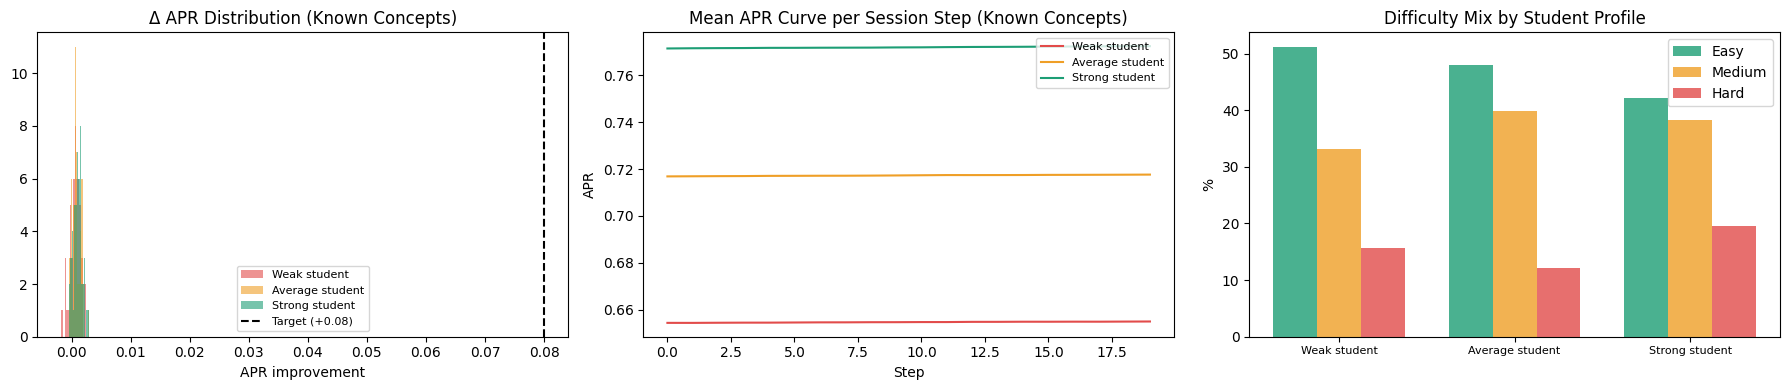


What good BC looks like:
  1. Weak students get more Easy/Medium assignments
  2. Strong students get more Medium/Hard assignments
  3. All profiles show positive Δ APR
  4. APR curves trend upward over session steps
  If difficulty mix is flat across profiles → BC did not learn the teacher's difficulty-matching behavior


In [ ]:
def eval_known_concepts(actor, tracker_template, concept_embeddings, cfg):
    print('\n' + '='*60)
    print('EVAL A — Known Concepts (DBE-KT22)')
    print('='*60)

    profiles = {
        'Weak student'    : lambda: {c: np.random.normal(-0.30, 0.10) for c in unique_concepts},
        'Average student' : lambda: {c: np.random.normal( 0.00, 0.05) for c in unique_concepts},
        'Strong student'  : lambda: {c: np.random.normal(+0.30, 0.10) for c in unique_concepts},
    }

    results = {}
    for profile_name, beta_fn in profiles.items():
        apr_starts, apr_finals, goals, diff_counts, apr_curves = [], [], [], [], []

        for session in range(cfg.EVAL_N_SESSIONS):
            # Fresh tracker per session
            t = PFATracker(unique_concepts, concept_embeddings, neighbours, sim_matrix, cfg)
            betas = beta_fn()
            for name, b in betas.items():
                t.beta_concept[t.idx[name]] = b

            apr_s, apr_f, apr_tgt, goal, log = run_eval_session(actor, t, cfg=cfg)
            apr_starts.append(apr_s)
            apr_finals.append(apr_f)
            goals.append(goal)
            diff_counts.append([sum(1 for e in log if e['level']==n)
                                 for n in cfg.LEVEL_NAMES])
            apr_curves.append([e['apr'] for e in log])

        results[profile_name] = {
            'apr_starts'  : np.array(apr_starts),
            'apr_finals'  : np.array(apr_finals),
            'apr_deltas'  : np.array(apr_finals) - np.array(apr_starts),
            'goal_rate'   : np.mean(goals),
            'diff_frac'   : np.array(diff_counts).mean(axis=0),
            'apr_curve'   : np.array([c + [c[-1]]*(cfg.EVAL_STEPS-len(c)) for c in apr_curves]).mean(axis=0),
        }

        print(f'\n  {profile_name}')
        print(f'    Mean APR start : {np.mean(apr_starts):.4f}')
        print(f'    Mean APR final : {np.mean(apr_finals):.4f}')
        print(f'    Mean Δ APR     : +{np.mean(apr_finals)-np.mean(apr_starts):.4f}')
        print(f'    Goal rate      : {np.mean(goals)*100:.1f}%  '
              f'(target: +{cfg.IMPROVEMENT_TARGET*100:.0f}pp)')
        df = np.array(diff_counts).mean(axis=0)
        total = df.sum()
        print(f'    Difficulty mix : '
              f'Easy={df[0]/total*100:.0f}%  '
              f'Med={df[1]/total*100:.0f}%  '
              f'Hard={df[2]/total*100:.0f}%')

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    colors = ['#E24B4A', '#EF9F27', '#1D9E75']

    for i, (name, res) in enumerate(results.items()):
        axes[0].hist(res['apr_deltas'], bins=15, alpha=0.6,
                     color=colors[i], label=name)
    axes[0].axvline(cfg.IMPROVEMENT_TARGET, linestyle='--', color='black',
                    label=f'Target (+{cfg.IMPROVEMENT_TARGET:.2f})')
    axes[0].set_title('Δ APR Distribution (Known Concepts)')
    axes[0].set_xlabel('APR improvement'); axes[0].legend(fontsize=8)


    for i, (name, res) in enumerate(results.items()):
        axes[1].plot(res['apr_curve'], color=colors[i], label=name)
    axes[1].set_title('Mean APR Curve per Session Step (Known Concepts)')
    axes[1].set_xlabel('Step'); axes[1].set_ylabel('APR'); axes[1].legend(fontsize=8)

    x = np.arange(len(results))
    w = 0.25
    diff_colors = ['#1D9E75', '#EF9F27', '#E24B4A']
    for li, (lname, dc) in enumerate(zip(cfg.LEVEL_NAMES, diff_colors)):
        fracs = [res['diff_frac'][li]/res['diff_frac'].sum()*100
                 for res in results.values()]
        axes[2].bar(x + li*w - w, fracs, w, label=lname, color=dc, alpha=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(list(results.keys()), fontsize=8)
    axes[2].set_title('Difficulty Mix by Student Profile')
    axes[2].set_ylabel('%'); axes[2].legend()

    plt.tight_layout(); plt.show()


    print('\nWhat good BC looks like:')
    print('  1. Weak students get more Easy/Medium assignments')
    print('  2. Strong students get more Medium/Hard assignments')
    print('  3. All profiles show positive Δ APR')
    print('  4. APR curves trend upward over session steps')
    print('  If difficulty mix is flat across profiles → BC did not learn'
          ' the teacher\'s difficulty-matching behavior')

    return results


results_known = eval_known_concepts(actor, tracker, concept_embeddings, cfg)

## Cell 11: Eval B New Concepts

In [ ]:

NEW_CONCEPTS = [
  
    ('Binary search tree',          3,   'medium CS data structure'),
    ('Hash table collision',        4,   'harder CS — requires understanding probing'),
    ('Merge sort',                  3,   'classic algorithm'),
    ('Big-O notation',              2,   'easy conceptual'),
    ('Dynamic programming',         5,   'hardest — requires recognizing subproblems'),
    ('Deadlock prevention',         4,   'advanced OS — relates to Transactions'),
    ('B-tree index',                4,   'hard — bridges DB and CS'),
    ('TCP handshake',               3,   'networking concept'),
]

def eval_new_concepts(actor, tracker, concept_embeddings, cfg, new_concepts, embed_model):
    print('\n' + '='*60)
    print('EVAL B — New Concepts (Not in DBE-KT22)')
    print('='*60)

    print('\nAdding new concepts...')
    new_names = []
    new_embeds = embed_model.encode(
        [n for n,_,_ in new_concepts],
        normalize_embeddings=True, show_progress_bar=False
    ).astype(np.float32)

    for (name, llm_diff, desc), emb in zip(new_concepts, new_embeds):
        beta_init = (llm_diff - cfg.LLM_BETA_MID) * cfg.LLM_BETA_SCALE
        tracker.add_concept(name, emb, beta_init)
        new_names.append(name)

    all_embeds_extended = np.vstack([concept_embeddings, new_embeds])
    print(f'\nTracker now has {len(tracker.concepts)} concepts '
          f'({len(unique_concepts)} known + {len(new_names)} new)')

    print('\nInitial policy on new concepts (uniform student, no prior interactions):')
    print(f'  {"Concept":<30} {"LLM diff":>8} {"β_init":>8} '
          f'{"P(Easy)":>8} {"P(Med)":>8} {"P(Hard)":>8} '
          f'{"Agent picks":>12}')
    print('  ' + '-'*86)

    tracker.reset()

    actor.eval()
    with torch.no_grad():
        tracker_tmp = tracker  # use tracker with extended concepts
        _, logits = actor.get_policy(tracker_tmp, cfg)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

    N_known = len(unique_concepts)

    for i, (name, llm_diff, _) in enumerate(new_concepts):
        ci       = N_known + i
        beta_i   = tracker.beta_concept[ci]
        p_easy   = tracker.predict(name, 0)
        p_med    = tracker.predict(name, 1)
        p_hard   = tracker.predict(name, 2)

        # Agent's probability mass over this concept's 3 actions
        concept_probs = probs[ci*3:(ci+1)*3]
        best_level    = cfg.LEVEL_NAMES[np.argmax(concept_probs)]
        total_prob    = concept_probs.sum()

        print(f'  {name:<30} {llm_diff:>8} {beta_i:>8.3f} '
              f'{p_easy:>8.3f} {p_med:>8.3f} {p_hard:>8.3f} '
              f'{best_level:>12}  (p_mass={total_prob:.4f})')

    print('\nSemantic neighbours (validates embedding generalization):')
    for i, (name, _, _) in enumerate(new_concepts):
        ci   = N_known + i
        nbrs = tracker.neighbours[ci]
        nbr_names = [tracker.concepts[j] for j in nbrs]
        sims      = [tracker.sim_matrix[ci, j] for j in nbrs]
        print(f'  {name:<30} → {", ".join(f"{n} ({s:.2f})" for n,s in zip(nbr_names,sims))}')

    print('\nRunning eval sessions on mixed concept set...')
    apr_starts, apr_finals, goals, new_concept_selections = [], [], [], []

    for session in range(cfg.EVAL_N_SESSIONS):
        t = PFATracker(
            tracker.concepts,
            tracker.embeddings,
            tracker.neighbours,
            tracker.sim_matrix,
            cfg
        )
    
        t.beta_concept = tracker.beta_concept.copy()
     
        for ci in range(N_known):
            t.beta_concept[ci] += np.random.normal(0, 0.1)

        apr_s, apr_f, apr_tgt, goal, log = run_eval_session(actor, t, cfg=cfg)
        apr_starts.append(apr_s)
        apr_finals.append(apr_f)
        goals.append(goal)

        # Count how many times new concepts were selected
        new_sel = sum(1 for e in log if e['concept'] in new_names)
        new_concept_selections.append(new_sel / len(log))

    print(f'\n  Mean APR start  : {np.mean(apr_starts):.4f}')
    print(f'  Mean APR final  : {np.mean(apr_finals):.4f}')
    print(f'  Mean Δ APR      : +{np.mean(apr_finals)-np.mean(apr_starts):.4f}')
    print(f'  Goal rate       : {np.mean(goals)*100:.1f}%')
    print(f'  New concept sel : {np.mean(new_concept_selections)*100:.1f}% of steps')
    print(f'  (expected ~{len(new_names)/(len(unique_concepts)+len(new_names))*100:.0f}% if uniform)')

    print('\nSingle verbose session (look for new concepts being assigned):')
    print('-'*80)
    t_verbose = PFATracker(
        tracker.concepts, tracker.embeddings,
        tracker.neighbours, tracker.sim_matrix, cfg
    )
    t_verbose.beta_concept = tracker.beta_concept.copy()
    run_eval_session(actor, t_verbose, cfg=cfg, verbose=True)

    return apr_starts, apr_finals, goals, new_concept_selections


apr_s_new, apr_f_new, goals_new, sel_new = eval_new_concepts(
    actor, tracker, concept_embeddings, cfg, NEW_CONCEPTS, embed_model
)


EVAL B — New Concepts (Not in DBE-KT22)

Adding new concepts...
  Added "Binary search tree" (beta_init=-0.000) -> P(Easy)=0.807  P(Med)=0.739  P(Hard)=0.605
  Added "Hash table collision" (beta_init=-0.400) -> P(Easy)=0.738  P(Med)=0.655  P(Hard)=0.507
  Added "Merge sort" (beta_init=-0.000) -> P(Easy)=0.807  P(Med)=0.739  P(Hard)=0.605
  Added "Big-O notation" (beta_init=0.400) -> P(Easy)=0.862  P(Med)=0.808  P(Hard)=0.696
  Added "Dynamic programming" (beta_init=-0.800) -> P(Easy)=0.653  P(Med)=0.559  P(Hard)=0.408
  Added "Deadlock prevention" (beta_init=-0.400) -> P(Easy)=0.738  P(Med)=0.655  P(Hard)=0.507
  Added "B-tree index" (beta_init=-0.400) -> P(Easy)=0.738  P(Med)=0.655  P(Hard)=0.507
  Added "TCP handshake" (beta_init=-0.000) -> P(Easy)=0.807  P(Med)=0.739  P(Hard)=0.605

Tracker now has 77 concepts (69 known + 8 new)

Initial policy on new concepts (uniform student, no prior interactions):
  Concept                        LLM diff   β_init  P(Easy)   P(Med)  P(Hard)  Ag

## Cell 12: BC Checks



BC SANITY CHECKS

  Δ APR (n=100 sessions):
    BC agent  : mean=+0.0008  std=0.0007  goal_rate=0.0%
    Random    : mean=+0.0019  std=0.0011  goal_rate=0.0%

    BC > Random: NO ✗ — BC did not improve over random

  Difficulty adaptation (does agent assign harder to stronger students?):
    Weak student mean level   : 0.655  (0=Easy, 1=Med, 2=Hard)
    Strong student mean level : 0.770
    Adapts difficulty: YES ✓


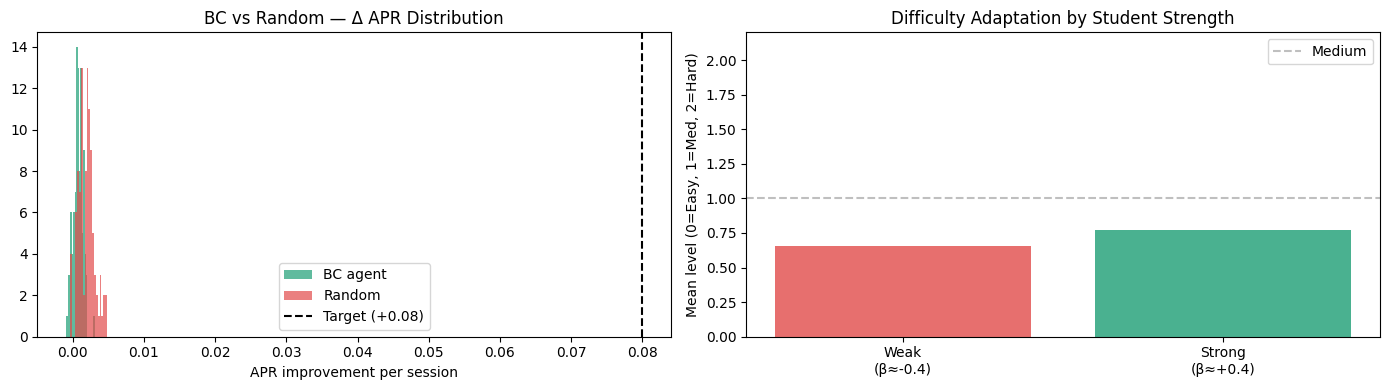

In [ ]:
def run_random_session(tracker, cfg):
    N = len(tracker.concepts)
    L = cfg.N_LEVELS
    apr_start, _ = tracker.reset()
    for _ in range(cfg.EVAL_STEPS):
        ci    = np.random.randint(N)
        level = np.random.randint(L)
        p_correct = tracker.predict(tracker.concepts[ci], level)
        correct   = int(np.random.random() < p_correct)
        tracker.update(tracker.concepts[ci], level, correct)
        if tracker.goal_met(): break
    return apr_start, tracker.compute_apr(), tracker.goal_met()


def bc_sanity_checks(actor, tracker_template, concept_embeddings, cfg, n=100):
    print('\n' + '='*60)
    print('BC SANITY CHECKS')
    print('='*60)


    bc_deltas, rnd_deltas = [], []
    bc_goals,  rnd_goals  = [], []

    for _ in range(n):
        betas = {c: np.random.normal(0, 0.2) for c in tracker_template.concepts}

        # BC agent
        t_bc = PFATracker(tracker_template.concepts, tracker_template.embeddings,
                          tracker_template.neighbours, tracker_template.sim_matrix, cfg)
        for name, b in betas.items():
            t_bc.beta_concept[t_bc.idx[name]] = b
        s, f, _, g, _ = run_eval_session(actor, t_bc, cfg=cfg)
        bc_deltas.append(f - s); bc_goals.append(g)

        # Random agent
        t_rnd = PFATracker(tracker_template.concepts, tracker_template.embeddings,
                           tracker_template.neighbours, tracker_template.sim_matrix, cfg)
        for name, b in betas.items():
            t_rnd.beta_concept[t_rnd.idx[name]] = b
        rs, rf, rg = run_random_session(t_rnd, cfg)
        rnd_deltas.append(rf - rs); rnd_goals.append(rg)

    print(f'\n  Δ APR (n={n} sessions):')
    print(f'    BC agent  : mean={np.mean(bc_deltas):+.4f}  '
          f'std={np.std(bc_deltas):.4f}  '
          f'goal_rate={np.mean(bc_goals)*100:.1f}%')
    print(f'    Random    : mean={np.mean(rnd_deltas):+.4f}  '
          f'std={np.std(rnd_deltas):.4f}  '
          f'goal_rate={np.mean(rnd_goals)*100:.1f}%')

    bc_better = np.mean(bc_deltas) > np.mean(rnd_deltas)
    print(f'\n    BC > Random: {"YES ✓" if bc_better else "NO ✗ - BC did not improve over random"}')

    print('\n  Difficulty adaptation (does agent assign harder to stronger students?):')
    weak_diff, strong_diff = [], []
    for _ in range(30):
        for profile, sign in [('weak', -0.4), ('strong', +0.4)]:
            betas = {c: np.random.normal(sign, 0.05) for c in unique_concepts}
            t = PFATracker(unique_concepts, concept_embeddings, neighbours, sim_matrix, cfg)
            for name, b in betas.items(): t.beta_concept[t.idx[name]] = b
            _, _, _, _, log = run_eval_session(actor, t, cfg=cfg)
            avg_level = np.mean([cfg.LEVEL_NAMES.index(e['level']) for e in log])
            if profile == 'weak':
                weak_diff.append(avg_level)
            else:
                strong_diff.append(avg_level)

    print(f'    Weak student mean level   : {np.mean(weak_diff):.3f}  '
          f'(0=Easy, 1=Med, 2=Hard)')
    print(f'    Strong student mean level : {np.mean(strong_diff):.3f}')
    adapted = np.mean(strong_diff) > np.mean(weak_diff)
    print(f'    Adapts difficulty: {"YES ✓" if adapted else "NO ✗"}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(bc_deltas,  bins=20, alpha=0.7, color='#1D9E75', label='BC agent')
    axes[0].hist(rnd_deltas, bins=20, alpha=0.7, color='#E24B4A', label='Random')
    axes[0].axvline(cfg.IMPROVEMENT_TARGET, linestyle='--', color='black',
                    label=f'Target (+{cfg.IMPROVEMENT_TARGET:.2f})')
    axes[0].set_title('BC vs Random — Δ APR Distribution')
    axes[0].set_xlabel('APR improvement per session'); axes[0].legend()

    axes[1].bar(['Weak\n(β≈-0.4)', 'Strong\n(β≈+0.4)'],
                [np.mean(weak_diff), np.mean(strong_diff)],
                color=['#E24B4A', '#1D9E75'], alpha=0.8)
    axes[1].set_ylim(0, 2.2)
    axes[1].axhline(1.0, linestyle='--', color='gray', alpha=0.5, label='Medium')
    axes[1].set_title('Difficulty Adaptation by Student Strength')
    axes[1].set_ylabel('Mean level (0=Easy, 1=Med, 2=Hard)')
    axes[1].legend()

    plt.tight_layout(); plt.show()

    return bc_deltas, rnd_deltas


bc_deltas, rnd_deltas = bc_sanity_checks(actor, tracker, concept_embeddings, cfg)

In [ ]:
print('\n' + '='*60)
print('  SUMMARY')
print('='*60)

final_val_ce  = val_losses[-1]
random_ce     = math.log(len(unique_concepts) * cfg.N_LEVELS)
bc_delta_mean = np.mean(bc_deltas)
rnd_delta_mean= np.mean(rnd_deltas)

checks = [
    ('BC val CE < random CE',
     final_val_ce < random_ce,
     f'{final_val_ce:.4f} < {random_ce:.4f}'),

    ('BC Δ APR > Random Δ APR',
     bc_delta_mean > rnd_delta_mean,
     f'{bc_delta_mean:+.4f} vs {rnd_delta_mean:+.4f}'),

    ('Positive mean Δ APR (known concepts)',
     bc_delta_mean > 0,
     f'{bc_delta_mean:+.4f}'),

    ('Positive mean Δ APR (new concepts)',
     float(np.mean(apr_f_new) - np.mean(apr_s_new)) > 0,
     f'{float(np.mean(apr_f_new)-np.mean(apr_s_new)):+.4f}'),

    ('New concepts receive assignments',
     np.mean(sel_new) > 0.01,
     f'{np.mean(sel_new)*100:.1f}% of steps'),

    ('AttentionEncoder (no mean pooling)',
     True,
     'Full cross-attention at each step'),

    ('APR-relative goal',
     True,
     f'+{cfg.IMPROVEMENT_TARGET*100:.0f}pp from student start'),
]

all_pass = True
for label, ok, detail in checks:
    print(f'  [{"PASS" if ok else "FAIL"}] {label:<45} {detail}')
    if not ok: all_pass = False

print()
if all_pass:
    print('  All checks passed. BC warm-up is working.')
else:
    if final_val_ce >= random_ce:
        print('  BC CE not below random -> increase BC_EPOCHS or decrease BC_LR')
    if bc_delta_mean <= rnd_delta_mean:
        print('  BC not better than random -> training did not converge')

print('='*60)